In [1]:
from google.colab import files

uploaded = files.upload()

Saving iris.csv to iris.csv


First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Features:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

Target classes:
['se

Text(0.5, 0, 'Predicted Label')

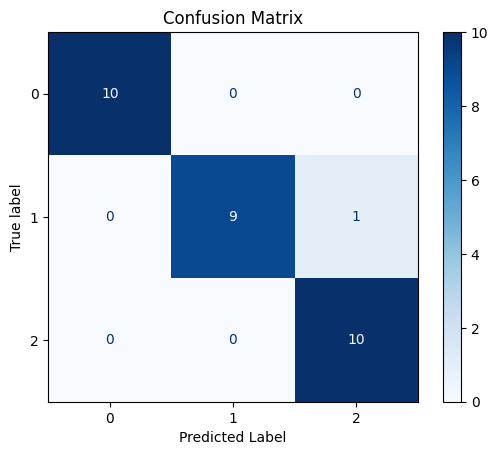

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1. Load Dataset

df = pd.read_csv("iris.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# 2. Select Features and Target
# Remove unnecessary column if present
# Example: Iris dataset may contain an "Id" column
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

# Target column
target_column = "species"

# Features
X = df.drop(target_column, axis=1)

# Target
y = df[target_column]

print("\nFeatures:")
print(X.columns)

print("\nTarget classes:")
print(y.unique())

# 3. Convert Categorical Target to Numbers
# Convert target labels such as:
# setosa, versicolor, virginica
# into numerical values

y = y.astype("category").cat.codes

print("\nEncoded target:")
print(y.unique())

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# 5. Train a Classifier
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

# 6. Make Predictions
y_pred = model.predict(X_test)

# 7. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nModel Evaluation")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 9. Display Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")